# 🚗 Análisis Exploratorio — Car Price Dataset

**Problema de negocio:** Limpiar y preparar los datos de autos para un modelo de regresión
que predecirá el **Precio Sugerido (MSRP)** a partir de características técnicas del vehículo.

**¿Por qué predecir el MSRP?**  
Las concesionarias y plataformas de venta de autos usados necesitan estimar el precio
justo de un vehículo. Un modelo entrenado con estos datos automatiza esa tarea con mayor
precisión que una estimación manual.

**Diccionario de Variables Clave:**
| Variable | Tipo | Descripción |
|---|---|---|
| `Make` | Categórica | Marca del auto (BMW, Toyota, etc.) |
| `Model` | Categórica | Modelo — 915 valores únicos (alta cardinalidad) |
| `Year` | Numérica | Año de fabricación (1990–2017) |
| `Engine HP` | Numérica | Potencia en caballos de fuerza |
| `Transmission Type` | Categórica | Contiene `'UNKNOWN'` enmascarado |
| `Market Category` | Categórica | 31.4% de valores nulos |
| `highway MPG / city mpg` | Numérica | Consumo de combustible |
| `MSRP` | Numérica | **Variable Objetivo** — Precio sugerido (USD) |

In [1]:
# ==========================================
# IMPORTACIONES
# ==========================================

import pandas as pd          # Manejo de tablas de datos (DataFrames)
import numpy as np           # Matemáticas: arrays, clip, quantile
import matplotlib.pyplot as plt  # Gráficos base
import seaborn as sns        # Gráficos estadísticos más bonitos
import os
import warnings
warnings.filterwarnings('ignore')

# Estilo visual para todos los gráficos del notebook
sns.set_theme(style='whitegrid', palette='muted')

# Crear carpeta outputs/ si no existe (aquí guardaremos todas las visualizaciones)
os.makedirs('../outputs', exist_ok=True)

# Cargar el dataset original (nunca modificamos este archivo)
df_raw = pd.read_csv('../data/raw/data.csv')
print(f'✅ Dataset cargado. Dimensiones: {df_raw.shape}')

✅ Dataset cargado. Dimensiones: (11914, 16)


## 1. Inspección General del Dataset

In [2]:
# .info() muestra: cantidad de filas, tipo de cada columna y si tiene nulos
# Es el primer paso siempre — conocer la 'radiografía' del dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [3]:
# .describe() muestra estadísticas de columnas numéricas
# count, mean, std, min, Q1(25%), mediana(50%), Q3(75%), max
df_raw.describe().round(2)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.00,11845.00,11884.00,11908.00,11914.00,11914.00,11914.00,11914.00
mean,2010.38,249.39,5.63,3.44,26.64,19.73,1554.91,40594.74
std,7.58,109.19,1.78,0.88,8.86,8.99,1441.86,60109.10
min,1990.00,55.00,0.00,2.00,12.00,7.00,2.00,2000.00
25%,2007.00,170.00,4.00,2.00,22.00,16.00,549.00,21000.00
50%,2015.00,227.00,6.00,4.00,26.00,18.00,1385.00,29995.00
75%,2016.00,300.00,6.00,4.00,30.00,22.00,2009.00,42231.25
max,2017.00,1001.00,16.00,4.00,354.00,137.00,5657.00,2065902.00


In [4]:
# Tabla resumen de calidad de datos por columna
# isnull() → tabla de True/False; .mean() → porcentaje de nulos
resumen_nulos = pd.DataFrame({
    'Tipo de dato': df_raw.dtypes.astype(str),
    'Nulos reales':  df_raw.isnull().sum(),
    '% Nulos':       (df_raw.isnull().mean() * 100).round(1),
    'Valores únicos': df_raw.nunique()
})
print('=== RESUMEN DE CALIDAD DE DATOS ===')
print(resumen_nulos.to_string())

=== RESUMEN DE CALIDAD DE DATOS ===
                  Tipo de dato  Nulos reales  % Nulos  Valores únicos
Make                       str             0      0.0              48
Model                      str             0      0.0             915
Year                     int64             0      0.0              28
Engine Fuel Type           str             3      0.0              10
Engine HP              float64            69      0.6             356
Engine Cylinders       float64            30      0.3               9
Transmission Type          str             0      0.0               5
Driven_Wheels              str             0      0.0               4
Number of Doors        float64             6      0.1               3
Market Category            str          3742     31.4              71
Vehicle Size               str             0      0.0               3
Vehicle Style              str             0      0.0              16
highway MPG              int64             0      0.0 

## 2. El Problema de los Valores Enmascarados ('UNKNOWN')

En muchos datasets reales, los nulos no vienen como `NaN` sino escondidos como texto.  
En este caso, `Transmission Type` tiene 19 registros con el string `'UNKNOWN'`.  
Pandas **no los detecta** con `isnull()` — debemos buscarlos explícitamente.

--- Conteo de UNKNOWN enmascarado por columna ---
Transmission Type    19
dtype: int64

--- Distribución de Transmission Type (nota el UNKNOWN) ---
Transmission Type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64


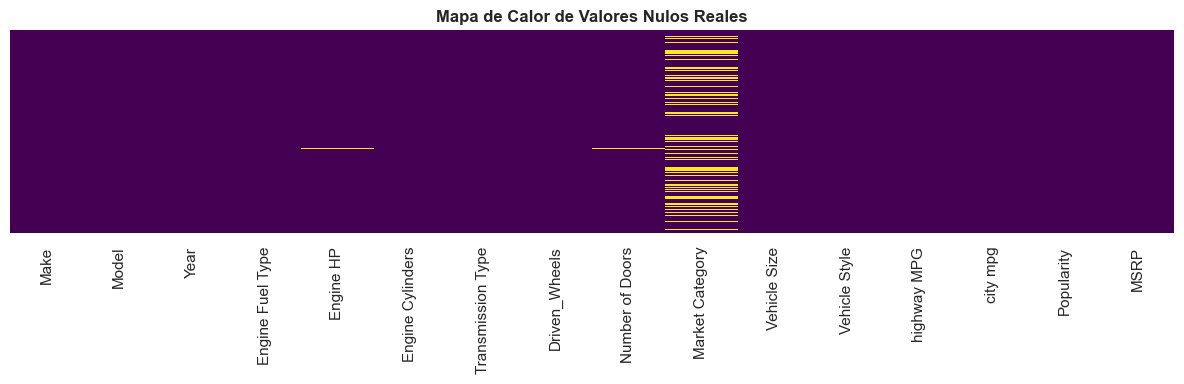

✅ Gráfico guardado en outputs/


In [5]:
# Buscamos el string 'UNKNOWN' columna por columna
# == 'UNKNOWN' crea una tabla de True/False — .sum() cuenta los True
print('--- Conteo de UNKNOWN enmascarado por columna ---')
conteo_unknown = (df_raw == 'UNKNOWN').sum()
print(conteo_unknown[conteo_unknown > 0].sort_values(ascending=False))

print('\n--- Distribución de Transmission Type (nota el UNKNOWN) ---')
print(df_raw['Transmission Type'].value_counts())

# Mapa de calor: visualiza dónde están los nulos reales
plt.figure(figsize=(12, 4))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Mapa de Calor de Valores Nulos Reales", fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/grafico_00_mapa_nulos.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/')

## 3. Operaciones Avanzadas de Pandas

Antes de limpiar, exploramos con operaciones avanzadas para entender mejor
qué factores afectan el precio y fundamentar nuestras decisiones técnicas.

In [6]:
# --- OPERACIÓN 1: GroupBy múltiple con agregaciones ---
# Analiza el MSRP promedio agrupando por tamaño de vehículo Y tipo de transmisión
# Esto responde: ¿cambia el precio según la combinación tamaño + transmisión?
msrp_por_grupo = (
    df_raw
    .groupby(['Vehicle Size', 'Transmission Type'])['MSRP']
    .agg(
        Promedio='mean',
        Mediana='median',
        Cantidad='count'
    )
    .round(0)
    .sort_values('Promedio', ascending=False)
)
print('=== MSRP por Tamaño × Transmisión (GroupBy Múltiple) ===')
print(msrp_por_grupo.head(10).to_string())

=== MSRP por Tamaño × Transmisión (GroupBy Múltiple) ===
                                Promedio   Mediana  Cantidad
Vehicle Size Transmission Type                              
Large        AUTOMATED_MANUAL   144657.0  114550.0        38
Compact      AUTOMATED_MANUAL   100302.0   35975.0       416
Midsize      AUTOMATED_MANUAL    87613.0   37968.0       172
Large        DIRECT_DRIVE        85256.0   79700.0        18
             AUTOMATIC           56874.0   40845.0      2464
Midsize      DIRECT_DRIVE        41009.0   49800.0         5
             AUTOMATIC           38223.0   33545.0      3678
Compact      DIRECT_DRIVE        32894.0   32100.0        45
Midsize      MANUAL              28885.0   23945.0       513
Compact      MANUAL              28058.0   18290.0      2173


In [7]:
# --- OPERACIÓN 2: Filtro avanzado con múltiples condiciones ---
# Identifica autos de alto rendimiento (>400 HP) a precio accesible (<$60K)
# Útil para detectar segmentos de mercado interesantes
filtro_avanzado = df_raw[
    (df_raw['Engine HP'] > 400) &
    (df_raw['MSRP'] < 60_000) &
    (df_raw['Transmission Type'] != 'UNKNOWN') &
    (df_raw['Year'] >= 2010)
].copy()

print(f'Autos >400HP, <$60K, desde 2010: {len(filtro_avanzado)} registros')
print()

# Agrupamos por marca para ver quién ofrece mejor potencia/precio
mejor_relacion = filtro_avanzado.groupby('Make').agg(
    HP_promedio=('Engine HP', 'mean'),
    Precio_promedio=('MSRP', 'mean'),
    Modelos=('Model', 'count')
).round(0).sort_values('HP_promedio', ascending=False)
print('=== Marcas con mejor relación Potencia/Precio ===')
print(mejor_relacion.head(8).to_string())

Autos >400HP, <$60K, desde 2010: 78 registros

=== Marcas con mejor relación Potencia/Precio ===
           HP_promedio  Precio_promedio  Modelos
Make                                            
Dodge            497.0          44648.0       18
Ford             493.0          44502.0       19
Chevrolet        451.0          49052.0       28
Hyundai          423.0          50917.0        3
Cadillac         420.0          59648.0        2
Genesis          420.0          54550.0        1
Infiniti         420.0          58825.0        2
Kia              420.0          57200.0        2


In [8]:
# --- OPERACIÓN 3: Pivot Table (reshape de datos) ---
# Crea una tabla cruzada de MSRP mediano por tracción × tamaño
# Equivalente a un JOIN cruzado que resume información multidimensional
pivot_precio = df_raw.pivot_table(
    values='MSRP',
    index='Driven_Wheels',
    columns='Vehicle Size',
    aggfunc='median',
    fill_value=0
).round(0)

print('=== PIVOT: MSRP Mediano por Tracción × Tamaño del Vehículo ===')
print(pivot_precio.to_string())

=== PIVOT: MSRP Mediano por Tracción × Tamaño del Vehículo ===
Vehicle Size       Compact    Large  Midsize
Driven_Wheels                               
all wheel drive    31185.0  57050.0  41955.0
four wheel drive   25185.0  39780.0  30995.0
front wheel drive  20195.0  32325.0  27150.0
rear wheel drive   30575.0  38125.0  35145.0


## 4. Variable Objetivo: MSRP

¿Cómo se distribuye el precio? ¿Hay outliers que distorsionen el modelo?

--- Estadísticas del MSRP (Variable Objetivo) ---
Mediana:  $    29,995  ← valor central real del mercado
Media:    $    40,595  ← inflada por autos de lujo
Máximo:   $ 2,065,902  ← Bugatti Veyron

💡 Media >> Mediana → distribución sesgada por outliers extremos
   Decisión: aplicar Winsorización (Capping IQR) sin eliminar filas


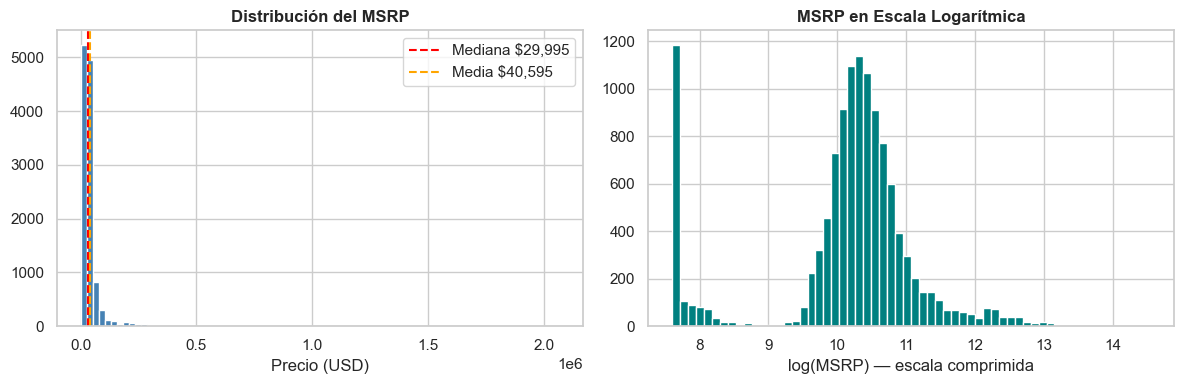

✅ Gráfico guardado en outputs/


In [9]:
print('--- Estadísticas del MSRP (Variable Objetivo) ---')
print(f'Mediana:  ${df_raw["MSRP"].median():>10,.0f}  ← valor central real del mercado')
print(f'Media:    ${df_raw["MSRP"].mean():>10,.0f}  ← inflada por autos de lujo')
print(f'Máximo:   ${df_raw["MSRP"].max():>10,.0f}  ← Bugatti Veyron')
print()
print('💡 Media >> Mediana → distribución sesgada por outliers extremos')
print('   Decisión: aplicar Winsorización (Capping IQR) sin eliminar filas')

# Gráfico 1: Distribución del MSRP
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma normal — muestra el sesgo (la 'cola' larga a la derecha)
axes[0].hist(df_raw['MSRP'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(df_raw['MSRP'].median(), color='red', linestyle='--',
                label=f'Mediana ${df_raw["MSRP"].median():,.0f}')
axes[0].axvline(df_raw['MSRP'].mean(), color='orange', linestyle='--',
                label=f'Media ${df_raw["MSRP"].mean():,.0f}')
axes[0].set_title('Distribución del MSRP', fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].legend()

# Escala log — muestra la distribución real sin que Bugatti aplaste todo
axes[1].hist(np.log1p(df_raw['MSRP']), bins=60, color='teal', edgecolor='white')
axes[1].set_title('MSRP en Escala Logarítmica', fontweight='bold')
axes[1].set_xlabel('log(MSRP) — escala comprimida')

plt.tight_layout()
plt.savefig('../outputs/grafico_01_distribucion_msrp.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/')

## 5. Outliers y Efecto de la Winsorización

**¿Qué es la Winsorización (Capping)?**  
En lugar de *eliminar* filas con valores extremos (perdemos datos valiosos),
*recortamos* los valores al límite estadístico del IQR.  
El Bugatti de $2M pasa a $74K en los datos — pero el auto **sigue en el dataset**.

Q1: $21,000 | Q3: $42,231 | IQR: $21,231
Límite superior: $74,078
Outliers cappados: 996 autos de lujo
Filas originales: 11914 → Filas después: 11914 (¡Sin pérdida!)


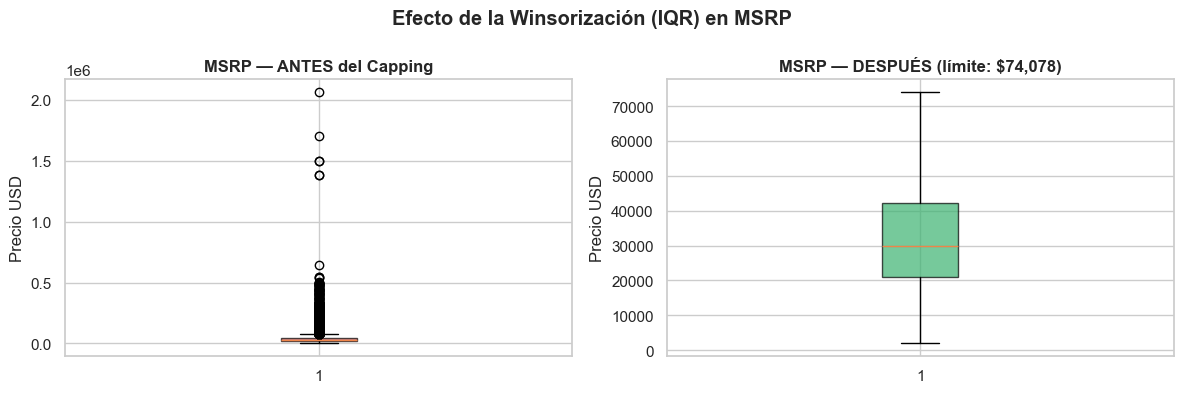

✅ Gráfico guardado en outputs/


In [10]:
# Calculamos los límites IQR para MSRP
Q1 = df_raw['MSRP'].quantile(0.25)   # 25% de los datos están por debajo
Q3 = df_raw['MSRP'].quantile(0.75)   # 75% de los datos están por debajo
IQR = Q3 - Q1                         # Rango intercuartílico
upper_bound = Q3 + 1.5 * IQR          # Límite matemático superior

# np.clip 'empuja' los valores fuera del rango hacia el límite
msrp_capped = np.clip(df_raw['MSRP'], 0, upper_bound)

print(f'Q1: ${Q1:,.0f} | Q3: ${Q3:,.0f} | IQR: ${IQR:,.0f}')
print(f'Límite superior: ${upper_bound:,.0f}')
print(f'Outliers cappados: {(df_raw["MSRP"] > upper_bound).sum()} autos de lujo')
print(f'Filas originales: {len(df_raw)} → Filas después: {len(msrp_capped)} (¡Sin pérdida!)')

# Gráfico 2: Antes vs Después de la Winsorización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_raw['MSRP'], patch_artist=True,
                boxprops=dict(facecolor='indianred', alpha=0.7))
axes[0].set_title('MSRP — ANTES del Capping', fontweight='bold')
axes[0].set_ylabel('Precio USD')

axes[1].boxplot(msrp_capped, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.7))
axes[1].set_title(f'MSRP — DESPUÉS (límite: ${upper_bound:,.0f})', fontweight='bold')
axes[1].set_ylabel('Precio USD')

plt.suptitle('Efecto de la Winsorización (IQR) en MSRP', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/grafico_02_winsorizacion_msrp.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/')

## 6. ¿Qué Factores Afectan el MSRP?

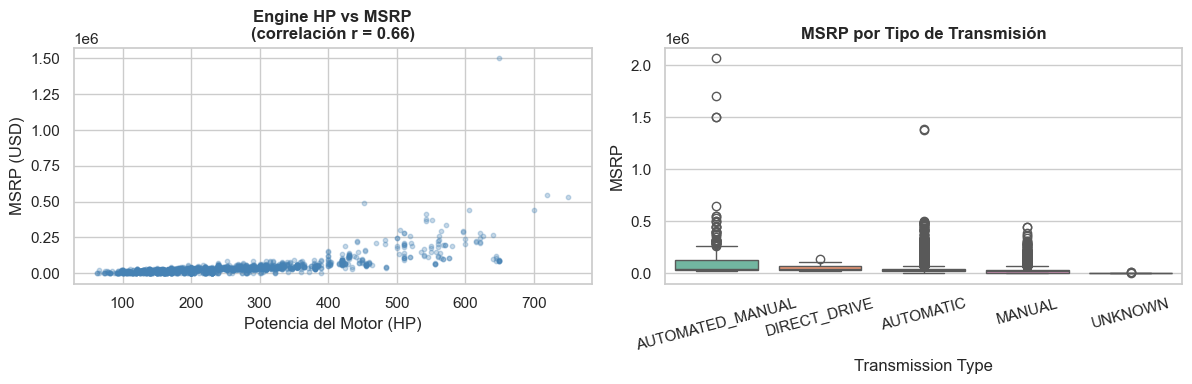

✅ Gráfico guardado en outputs/


In [11]:
# Gráfico 3: HP vs MSRP + Transmisión vs MSRP
# Responde directamente la pregunta del negocio:
# ¿qué características determinan el precio de un auto?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Muestra de 2000 puntos para que el gráfico no tarde demasiado
sample = df_raw.dropna(subset=['Engine HP']).sample(2000, random_state=42)

# Scatter: relación HP → Precio (correlación r=0.66)
axes[0].scatter(sample['Engine HP'], sample['MSRP'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Potencia del Motor (HP)')
axes[0].set_ylabel('MSRP (USD)')
axes[0].set_title('Engine HP vs MSRP\n(correlación r = 0.66)', fontweight='bold')

# Boxplot: precio por tipo de transmisión
orden = df_raw.groupby('Transmission Type')['MSRP'].median()\
              .sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_raw, x='Transmission Type', y='MSRP',
            order=orden, ax=axes[1], palette='Set2')
axes[1].set_title('MSRP por Tipo de Transmisión', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/grafico_03_factores_precio.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/')

## 7. Correlación entre Variables Numéricas

La correlación mide la relación lineal entre dos variables (valor entre -1 y 1):  
* **Cercano a 1**: cuando una sube, la otra también (ej. HP y precio)  
* **Cercano a -1**: cuando una sube, la otra baja (ej. MPG y precio)  
* **Cercano a 0**: no hay relación lineal

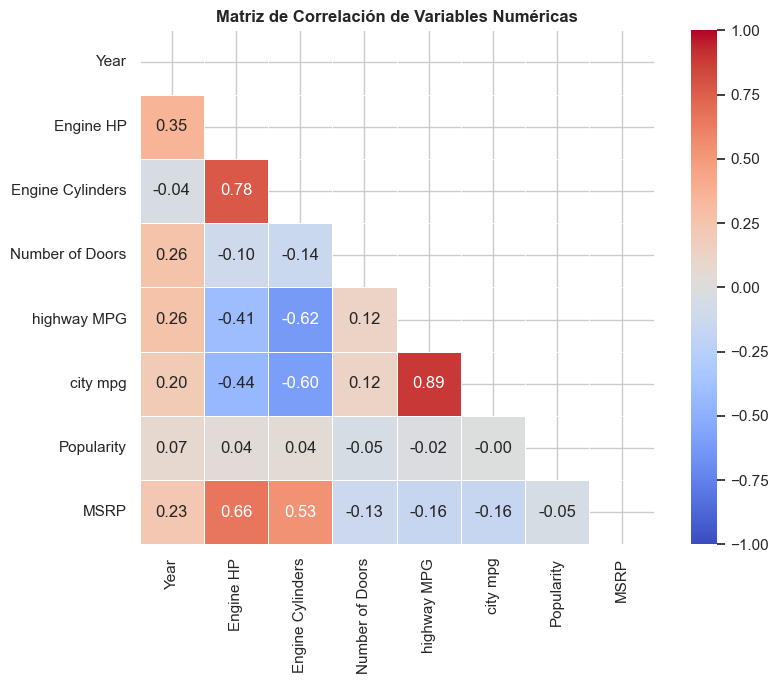

=== Correlación con MSRP (de mayor a menor) ===
  Engine HP           : +0.66 ↑
  Engine Cylinders    : +0.53 ↑
  Year                : +0.23 ↑
  Popularity          : -0.05 ↓
  Number of Doors     : -0.13 ↓
  city mpg            : -0.16 ↓
  highway MPG         : -0.16 ↓

💡 Engine HP (r=0.66) es el predictor numérico más fuerte del precio.
   highway MPG y city mpg tienen correlación 0.89 entre sí → redundantes.
✅ Gráfico guardado en outputs/


In [12]:
# Seleccionamos solo columnas numéricas
num_cols = df_raw.select_dtypes(include='number').columns
matriz_correlacion = df_raw[num_cols].corr()

# Máscara para mostrar solo el triángulo inferior (el superior es duplicado)
mask = np.zeros_like(matriz_correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacion,
            mask=mask,
            annot=True,          # Muestra el número en cada celda
            cmap='coolwarm',     # Azul=negativo, Rojo=positivo
            fmt='.2f',           # 2 decimales
            linewidths=0.5,
            vmin=-1, vmax=1,
            square=True)
plt.title('Matriz de Correlación de Variables Numéricas', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/grafico_04_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print('=== Correlación con MSRP (de mayor a menor) ===')
corr_msrp = matriz_correlacion['MSRP'].drop('MSRP').sort_values(ascending=False)
for var, r in corr_msrp.items():
    signo = '↑' if r > 0 else '↓'
    print(f'  {var:20s}: {r:+.2f} {signo}')
print()
print('💡 Engine HP (r=0.66) es el predictor numérico más fuerte del precio.')
print('   highway MPG y city mpg tienen correlación 0.89 entre sí → redundantes.')
print('✅ Gráfico guardado en outputs/')